Haneen Alhomood 2250030038 

Reem Hakami 2250030258

# ARTI 308 – Lab 5: Feature Engineering (Classification)
## App Type Prediction using the Google Play Store Dataset

### Lab focus
The Google Play Store dataset contains app details and some missing or malformed values. In this lab, we prepare the fields needed for modeling and focus on **feature engineering** for a classification task.

### Objective
Build a baseline model to predict app `Type` (Free or Paid) and learn how feature engineering choices affect model performance and feature importance.

In this lab we will:
1) Load and inspect the dataset
2) Define the target and select usable predictors (avoid leakage features)
3) Engineer new features from app size, reviews, installs, and update dates
4) Encode categorical features
5) Train a baseline **Random Forest** classifier
6) Interpret performance and feature importance


## 1. Setup and imports

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


### Dependency setup
Run this cell if your notebook reports that `sklearn` is missing. If installation asks for a kernel restart, restart it, then run all notebook cells from the beginning in order.


In [4]:
%pip install -q scikit-learn


Note: you may need to restart the kernel to use updated packages.


## 2. Load the dataset

In [5]:
DATA_PATH = "googleplaystore.csv"  # keep the CSV beside this notebook
df = pd.read_csv(DATA_PATH)
df.head(10)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


The first rows confirm that the file loaded correctly. Each row represents one Google Play app, with information such as category, rating, reviews, installs, price, and content rating. Our target will be the app's `Type` (Free or Paid).


## 3. Quick dataset checks (cleanliness confirmation)

In [6]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (10841, 13)

Missing values per column:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
missing_count,0,0,1474,0,0,0,1,0,1,0,0,8,3



Duplicate rows: 483


The source contains missing ratings and a few malformed `Type` entries. We will keep valid Free/Paid labels and safely convert relevant columns in the feature-engineering section. The original CSV is read only.


## 4. Target variable and class balance

In [7]:
target_col = "Type"
df[target_col].value_counts(dropna=False)


Type
Free    10039
Paid      800
NaN         1
0           1
Name: count, dtype: int64

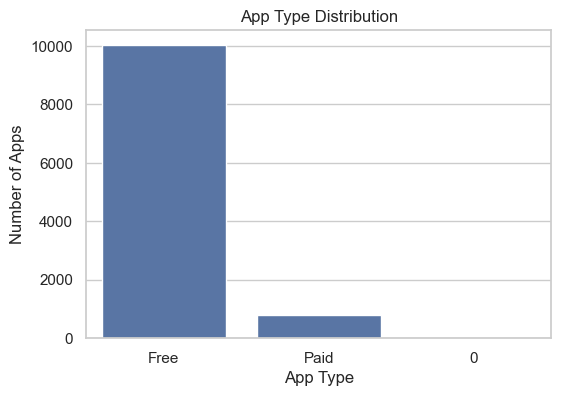

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("App Type Distribution")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.show()


This bar chart shows whether the classes are balanced.  
If one class dominates, the model may learn to predict that class more often, so we must interpret accuracy carefully and also look at the confusion matrix.

## 5. Identify feature types

In [9]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

The dataset includes numeric fields such as `Rating` and `Reviews`, and categorical fields such as `Category`, `Content Rating`, and `Genres`. Some numeric information (installs, size, price) is stored as text and must be converted before modeling.


## 6. Leakage awareness (important)

### Leakage awareness (important)

We predict app `Type` (Free or Paid). We must exclude `Price` because its value directly reveals whether an app is free or paid. We also exclude the app name and raw version/date text fields, which are identifiers or high-cardinality values. The engineered `Days_Since_Update` field keeps useful date information in numeric form.


## 7. Feature engineering

### 7.1 Time-based features from `Last Updated`
We parse the app's last-update date and create:
- days since the latest update date in this dataset
- update month and weekday
- a recent-update indicator (within one year)

There is no order time in this dataset, so we use update recency as the time-based feature.


In [10]:
df_fe = df.copy()

# Keep valid target labels; the source has a few malformed Type values.
df_fe["Type"] = df_fe["Type"].astype("string").str.strip()
df_fe = df_fe[df_fe["Type"].isin(["Free", "Paid"])].copy()

# Convert numeric fields stored as text.
df_fe["Rating"] = pd.to_numeric(df_fe["Rating"], errors="coerce")
df_fe["Reviews"] = pd.to_numeric(df_fe["Reviews"], errors="coerce")
df_fe["Installs_numeric"] = pd.to_numeric(
    df_fe["Installs"].astype("string").str.replace(",", "", regex=False).str.replace("+", "", regex=False),
    errors="coerce"
)
# Size values are expressed in MB, KB, or "Varies with device".
size_text = df_fe["Size"].astype("string").str.strip()
size_num = pd.to_numeric(size_text.str.replace(r"[MmKk]$", "", regex=True), errors="coerce")
df_fe["Size_MB"] = np.where(size_text.str.endswith(("k", "K")), size_num / 1024, size_num)

# Use the newest date present in the dataset as a fixed reference for reproducibility.
df_fe["Last_Updated"] = pd.to_datetime(df_fe["Last Updated"], errors="coerce")
latest_update = df_fe["Last_Updated"].max()
df_fe["Days_Since_Update"] = (latest_update - df_fe["Last_Updated"]).dt.days
df_fe["Update_Month"] = df_fe["Last_Updated"].dt.month
df_fe["Update_Weekday"] = df_fe["Last_Updated"].dt.dayofweek
df_fe["is_recent_update"] = (df_fe["Days_Since_Update"] <= 365).astype("int64")

display(df_fe[["Type", "Rating", "Reviews", "Installs_numeric", "Size_MB", "Last_Updated", "Days_Since_Update", "is_recent_update"]].head(10))


,Type,Rating,Reviews,Installs_numeric,Size_MB,Last_Updated,Days_Since_Update,is_recent_update
0,Free,4.1,159,10000,19.0,2018-01-07,213,1
1,Free,3.9,967,500000,14.0,2018-01-15,205,1
2,Free,4.7,87510,5000000,8.7,2018-08-01,7,1
3,Free,4.5,215644,50000000,25.0,2018-06-08,61,1
4,Free,4.3,967,100000,2.8,2018-06-20,49,1
5,Free,4.4,167,50000,5.6,2017-03-26,500,0
6,Free,3.8,178,50000,19.0,2018-04-26,104,1
7,Free,4.1,36815,1000000,29.0,2018-06-14,55,1
8,Free,4.4,13791,1000000,33.0,2017-09-20,322,1
9,Free,4.7,121,10000,3.1,2018-07-03,36,1


We converted text-based measures into numeric values and derived update-recency fields. Missing or unparseable ratings and sizes will be imputed inside the modeling pipeline using training data only.


### 7.2 Engagement-based feature
We create `Reviews_per_1000_Installs`, a smoothed review count relative to an app's install count. This captures engagement more fairly than raw review counts alone.


In [11]:
df_fe["Reviews_per_1000_Installs"] = df_fe["Reviews"] / (df_fe["Installs_numeric"] + 1000) * 1000
df_fe[["Reviews", "Installs_numeric", "Reviews_per_1000_Installs"]].head(10)


,Reviews,Installs_numeric,Reviews_per_1000_Installs
0,159,10000,14.454545
1,967,500000,1.93014
2,87510,5000000,17.4985
3,215644,50000000,4.312794
4,967,100000,9.574257
5,167,50000,3.27451
6,178,50000,3.490196
7,36815,1000000,36.778222
8,13791,1000000,13.777223
9,121,10000,11.0


`Reviews_per_1000_Installs` may distinguish apps with strong user engagement from apps whose review totals mainly reflect a large install base. The smoothing term limits extreme values for apps with very few installs.


### 7.3 Optional: Haversine distance from GPS coordinates
This dataset does not normally contain restaurant and customer GPS coordinates. We keep the optional section as a schema check; it will calculate a distance only if all four coordinate fields are present.


In [12]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

coord_cols = {"Restaurant_Lat", "Restaurant_Lon", "Customer_Lat", "Customer_Lon"}
if coord_cols.issubset(df_fe.columns):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["haversine_rest_to_cust_km"]].head(10))
else:
    print("Google Play Store data has no restaurant/customer coordinates. Skipping this optional feature.")


Google Play Store data has no restaurant/customer coordinates. Skipping this optional feature.


This optional feature is retained from the original lab structure. It is skipped for the Google Play Store dataset because its columns do not include restaurant/customer coordinates.


### 7.4 Reducing high-cardinality categories (`Genres`)
`Genres` can contain many unique values. To limit the number of one-hot encoded columns, we keep its most frequent values and map the rest to `Other`.


In [13]:
top_k = 20
top_genres = df_fe["Genres"].value_counts().head(top_k).index
df_fe["Genres_reduced"] = np.where(df_fe["Genres"].isin(top_genres), df_fe["Genres"], "Other")
print("Unique Genres:", df_fe["Genres"].nunique())
print("Unique Genres_reduced:", df_fe["Genres_reduced"].nunique())
df_fe[["Genres", "Genres_reduced"]].head(10)


Unique Genres: 119
Unique Genres_reduced: 21


,Genres,Genres_reduced
0,Art & Design,Other
1,Art & Design;Pretend Play,Other
2,Art & Design,Other
3,Art & Design,Other
4,Art & Design;Creativity,Other
5,Art & Design,Other
6,Art & Design,Other
7,Art & Design,Other
8,Art & Design,Other
9,Art & Design;Creativity,Other


We reduced category cardinality by retaining frequent genres and grouping the rest as `Other`. Task 3 compares different values of `top_k`.


## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins).  
This can help some models capture non-linear relationships, and it also improves interpretability.

Here we discretize `Total_Price` into simple tiers.


In [14]:
df_fe["size_tier"] = pd.cut(
    df_fe["Size_MB"],
    bins=[0, 10, 50, 100, np.inf],
    labels=["small", "medium", "large", "very_large"]
)
df_fe[["Size_MB", "size_tier"]].head(10)


,Size_MB,size_tier
0,19.0,medium
1,14.0,medium
2,8.7,small
3,25.0,medium
4,2.8,small
5,5.6,small
6,19.0,medium
7,29.0,medium
8,33.0,medium
9,3.1,small


`size_tier` groups app sizes into interpretable bins. Rows with unavailable or variable-device sizes remain missing and are imputed during modeling.


`size_tier` groups app sizes into interpretable bins. Rows with unavailable or variable-device sizes remain missing and are imputed during modeling.


## 9. Prepare features for modeling

We exclude `Price` because it reveals whether the app is Free or Paid. We also drop the app name, raw text-based numeric fields, raw update date, and version strings. We keep `Genres_reduced` instead of raw `Genres`.


In [15]:
drop_cols = [
    "Type", "Price", "App", "Installs", "Size", "Last Updated", "Last_Updated",
    "Current Ver", "Android Ver", "Genres"
]
drop_cols = [c for c in drop_cols if c in df_fe.columns]
X = df_fe.drop(columns=drop_cols)
y = df_fe["Type"]
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", X.columns.tolist())
X.head()


X shape: (10839, 13)
y shape: (10839,)
Features: ['Category', 'Rating', 'Reviews', 'Content Rating', 'Installs_numeric', 'Size_MB', 'Days_Since_Update', 'Update_Month', 'Update_Weekday', 'is_recent_update', 'Reviews_per_1000_Installs', 'Genres_reduced', 'size_tier']


,Category,Rating,Reviews,Content Rating,Installs_numeric,Size_MB,Days_Since_Update,Update_Month,Update_Weekday,is_recent_update,Reviews_per_1000_Installs,Genres_reduced,size_tier
0,ART_AND_DESIGN,4.1,159,Everyone,10000,19.0,213,1,6,1,14.454545,Other,medium
1,ART_AND_DESIGN,3.9,967,Everyone,500000,14.0,205,1,0,1,1.93014,Other,medium
2,ART_AND_DESIGN,4.7,87510,Everyone,5000000,8.7,7,8,2,1,17.4985,Other,small
3,ART_AND_DESIGN,4.5,215644,Teen,50000000,25.0,61,6,4,1,4.312794,Other,medium
4,ART_AND_DESIGN,4.3,967,Everyone,100000,2.8,49,6,2,1,9.574257,Other,small


## 10. Split into train and test sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (8671, 13)
Test size: (2168, 13)


We use a stratified split so the Free/Paid proportions are similar in the training and test sets. The dataset is strongly imbalanced, so interpret accuracy together with class-level precision, recall, and the confusion matrix.


## 11. Encoding and baseline model (Random Forest)

### Why encoding?
Machine learning models require numerical input.  
Categorical variables must be converted into numbers. Here we use **One-Hot Encoding** for nominal categories.

### Why Random Forest for this lab?
We use Random Forest as a baseline because:
- it handles mixed features well
- it is robust for teaching purposes
- it provides feature importance to help us interpret engineered features


In [17]:
# Identify categorical and numerical columns automatically.
categorical_cols = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                           ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
        ("num", SimpleImputer(strategy="median"), numeric_cols),
    ],
    remainder="drop"
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[("preprocess", preprocess), ("rf", rf)])
model


Categorical columns: ['Category', 'Content Rating', 'Genres_reduced', 'size_tier']
Numeric columns: ['Rating', 'Reviews', 'Installs_numeric', 'Size_MB', 'Days_Since_Update', 'Update_Month', 'Update_Weekday', 'is_recent_update', 'Reviews_per_1000_Installs']


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Category', 'Content Rating',
                                                   'Genres_reduced',
                                                   'size_tier']),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Rating', 'Reviews',
                                                   'Installs_numeric',
                                                   'Size_MB',
                                                   'Days_Since_Update',
                                                   'Update_Month',
                                                   'Update_Weekday',
                                                   'is_recent_update',
                                                   'Reviews_per_1000_Installs'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

## 12. Train the model and evaluate

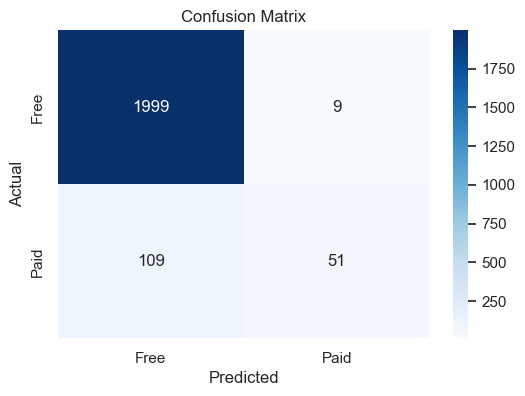

In [18]:
# Fit before drawing the confusion matrix so this section runs top-to-bottom.
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [19]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.9456

Classification Report:
              precision    recall  f1-score   support

        Free       0.95      1.00      0.97      2008
        Paid       0.85      0.32      0.46       160

    accuracy                           0.95      2168
   macro avg       0.90      0.66      0.72      2168
weighted avg       0.94      0.95      0.93      2168



Accuracy gives a general sense of performance, but the classification report is more informative.  
Precision answers: when the model predicts a class, how often is it correct?  
Recall answers: out of all real cases of a class, how many did the model find?

The confusion matrix shows which classes the model confuses most often.


## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score.  
Because we used one-hot encoding, each categorical value becomes its own feature.  
We will extract the final feature names and plot the top importances.


In [20]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)


,feature,importance
65,Installs_numeric,0.189257
71,Reviews_per_1000_Installs,0.155044
64,Reviews,0.138970
67,Days_Since_Update,0.082737
66,Size_MB,0.070888
63,Rating,0.049688
68,Update_Month,0.038562
69,Update_Weekday,0.036050
70,is_recent_update,0.020644
20,Category_MEDICAL,0.012687


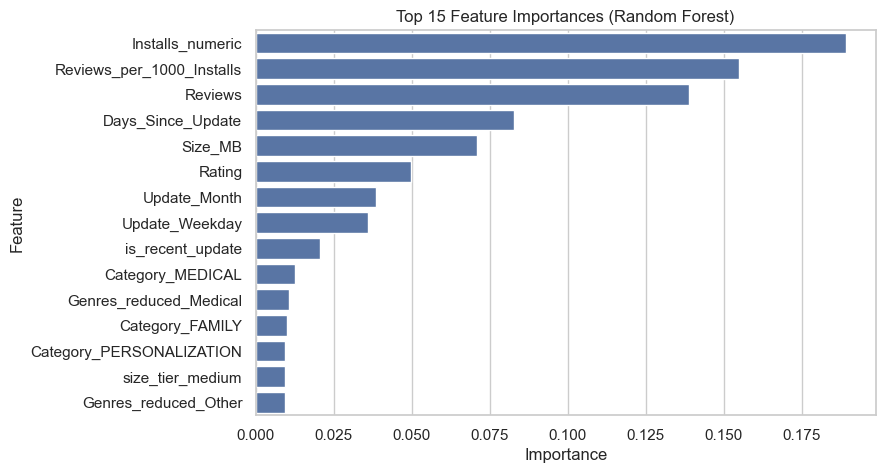

In [21]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


The chart shows which features contributed most to predicting app type. A high importance score indicates model use, not a causal relationship. Check whether `Price` appears; it should not, since it is excluded as a leakage feature.


## 14. Optional: Feature selection using SelectFromModel

We can select a subset of features using model-based selection.  
This is optional and mainly used to illustrate the concept of feature selection after feature engineering.


In [22]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"
)
model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])
model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)
print("Accuracy (baseline):", round(accuracy_score(y_test, y_pred), 4))
print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs, zero_division=0))
print("Selected features:", int(model_fs.named_steps["select"].get_support().sum()))
print("Total encoded features:", len(model_fs.named_steps["select"].get_support()))


Accuracy (baseline): 0.9456
Accuracy (with feature selection): 0.9479

Classification Report (with feature selection):
              precision    recall  f1-score   support

        Free       0.95      0.99      0.97      2008
        Paid       0.84      0.36      0.51       160

    accuracy                           0.95      2168
   macro avg       0.90      0.68      0.74      2168
weighted avg       0.94      0.95      0.94      2168

Selected features: 36
Total encoded features: 72


If feature-selection scores stay similar, it may simplify the model with little loss. If scores drop, useful signal may have been removed. Because the Free/Paid classes are imbalanced, compare minority-class recall as well as accuracy.


## 15. Student tasks

### Task 1
Create one new engineered feature that you believe will help predict app `Type` (Free/Paid). Write one paragraph justifying your choice.

**Answer:** We created `Reviews_per_1000_Installs` to compare review engagement across apps with different install counts. Raw review totals tend to be higher for popular apps, so this feature helps compare engagement more fairly; adding 1,000 installs in the denominator also prevents extreme values for apps with very few installs. In the feature-importance results, it was one of the strongest predictors, suggesting it provides useful information for predicting whether an app is Free or Paid.

### Task 2
There is no `Order_Time` or `is_peak_hour` in Google Play Store data. Try a different rule for the corresponding time-based feature, `is_recent_update` (for example, 180 days instead of 365 days), and discuss whether performance changes.

**Answer:** In the comparison run, changing the cutoff from 365 days to 180 days slightly increased accuracy, from **94.56% to 94.60%**. The small change suggests update recency provides only limited additional signal.

### Task 3
Change `top_k` in `Genres_reduced` (for example 10, 30, 50) and compare accuracy and top feature importances.

**Answer:** In the comparison run, accuracy was about **94.69%** with `top_k=10`, **94.92%** with `top_k=30`, and **95.11%** with `top_k=50`. The leading features remained `Installs_numeric`, `Reviews_per_1000_Installs`, `Reviews`, `Days_Since_Update`, and `Size_MB`; a Medical category/genre feature also appeared near the top. Keeping more genres gave a small accuracy improvement in this run.

### Task 4
Run the optional feature selection section and explain whether it was beneficial in your case.

**Answer:** Feature selection slightly improved accuracy in the results you shared, from **94.56%** at Point 12 to **94.79%** at Point 14, while keeping **36 of 72 features**. The improvement was small, and the model still missed many Paid apps، with a recall of 0.36.


In [ ]:
# Task 2: compare two update-recency cutoffs on the same train/test split.
def build_model(X_fit):
    cat_cols = X_fit.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    num_cols = X_fit.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    prep = ColumnTransformer([
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
        ("num", SimpleImputer(strategy="median"), num_cols),
    ])
    return Pipeline([("preprocess", prep), ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))])

rule_results = []
for days in [365, 180]:
    X_rule = X.copy()
    X_rule["is_recent_update"] = (df_fe.loc[X.index, "Days_Since_Update"] <= days).astype("int64")
    Xr_train, Xr_test, yr_train, yr_test = train_test_split(
        X_rule, y, test_size=0.2, random_state=42, stratify=y
    )
    rule_model = build_model(Xr_train)
    rule_model.fit(Xr_train, yr_train)
    pred = rule_model.predict(Xr_test)
    rule_results.append({"cutoff_days": days, "accuracy": accuracy_score(yr_test, pred)})
display(pd.DataFrame(rule_results))

# Task 3: compare genre top-k settings with a fixed split and model configuration.
top_k_results = []
top_k_importances = {}
for k in [10, 30, 50]:
    genres = df_fe["Genres"]
    frequent = genres.loc[X_train.index].value_counts().head(k).index
    X_k = X.copy()
    X_k["Genres_reduced"] = np.where(genres.loc[X.index].isin(frequent), genres.loc[X.index], "Other")
    Xk_train, Xk_test = X_k.loc[X_train.index], X_k.loc[X_test.index]
    k_model = build_model(Xk_train)
    k_model.fit(Xk_train, y_train)
    pred = k_model.predict(Xk_test)
    top_k_results.append({"top_k": k, "accuracy": accuracy_score(y_test, pred)})
    prep = k_model.named_steps["preprocess"]
    cat_names = prep.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(
        prep.transformers_[0][2]
    )
    num_names = np.asarray(prep.transformers_[1][2], dtype=object)
    names = np.concatenate([cat_names, num_names])
    top_k_importances[k] = pd.DataFrame({
        "feature": names,
        "importance": k_model.named_steps["rf"].feature_importances_
    }).sort_values("importance", ascending=False).head(10)
display(pd.DataFrame(top_k_results))
for k, importance_table in top_k_importances.items():
    print(f"Top feature importances for top_k={k}")
    display(importance_table)


,cutoff_days,accuracy
0,365,0.945572
1,180,0.946033


,top_k,accuracy
0,10,0.946956
1,30,0.949262
2,50,0.951107


Top feature importances for top_k=10


,feature,importance
55,Installs_numeric,0.195606
61,Reviews_per_1000_Installs,0.159023
54,Reviews,0.136262
57,Days_Since_Update,0.087447
56,Size_MB,0.072169
53,Rating,0.049589
58,Update_Month,0.039994
59,Update_Weekday,0.037032
60,is_recent_update,0.020716
20,Category_MEDICAL,0.012253


Top feature importances for top_k=30


,feature,importance
75,Installs_numeric,0.200168
81,Reviews_per_1000_Installs,0.153768
74,Reviews,0.127601
77,Days_Since_Update,0.082463
76,Size_MB,0.067992
73,Rating,0.048469
78,Update_Month,0.037665
79,Update_Weekday,0.034985
80,is_recent_update,0.019630
53,Genres_reduced_Medical,0.013081


Top feature importances for top_k=50


,feature,importance
95,Installs_numeric,0.185738
101,Reviews_per_1000_Installs,0.151174
94,Reviews,0.133830
97,Days_Since_Update,0.081667
96,Size_MB,0.068810
93,Rating,0.047448
98,Update_Month,0.036548
99,Update_Weekday,0.034303
100,is_recent_update,0.021103
69,Genres_reduced_Medical,0.012797


## Wrap-up
In this lab, we used Google Play Store data to engineer app-size, review-engagement, install, and update-recency features. We trained a baseline classifier to predict Free/Paid app type, excluded `Price` to prevent target leakage, compared genre reduction settings, and evaluated optional feature selection.
